# Fortune 500 Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = 'C:/Users/Nehal/OneDrive/Desktop/data/Fortune 500 Companies.csv'
df = pd.read_csv(data)
display(df)

,name,rank,year,industry,sector,headquarters_state,headquarters_city,market_value_mil,revenue_mil,profit_mil,asset_mil,employees,founder_is_ceo,female_ceo,newcomer_to_fortune_500,global_500
0,General Motors Corporation,1,1996,Motor Vehicles & Parts,NaN,MI,NaN,NaN,168828.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ford Motor Company,2,1996,Motor Vehicles & Parts,NaN,MI,NaN,NaN,137137.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Exxon Corporation,3,1996,Petroleum Refining,NaN,TX,NaN,NaN,110009.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Wal-Mart Stores, Inc.",4,1996,General Merchandisers,NaN,AR,NaN,NaN,93627.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AT&T Corp.,5,1996,Telecommunications,NaN,NY,NaN,NaN,79609.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13935,KKR,496,2023,Securities,Financials,NY,New York,45225.0,7273.0,841.0,277077.0,4150.0,no,no,no,no
13936,Equinix,497,2023,Real Estate,Financials,CA,Redwood City,66873.0,7263.0,704.0,30311.0,12097.0,no,no,no,no
13937,Sonoco Products,498,2023,"Packaging, Containers",Materials,SC,Hartsville,5975.0,7251.0,466.0,7053.0,22000.0,no,no,yes,no
13938,ServiceNow,499,2023,Computer Software,Technology,CA,Santa Clara,94338.0,7245.0,325.0,13299.0,20433.0,no,no,yes,no


## Exploratory Data Analysis

For our data analysis we will consider the columns: Year, Rank, Company, Revenue, Profit

In [4]:
eda_df = df[['year','rank','industry','revenue_mil','profit_mil']]
eda_df.head()

,year,rank,industry,revenue_mil,profit_mil
0,1996,1,Motor Vehicles & Parts,168828.6,NaN
1,1996,2,Motor Vehicles & Parts,137137.0,NaN
2,1996,3,Petroleum Refining,110009.0,NaN
3,1996,4,General Merchandisers,93627.0,NaN
4,1996,5,Telecommunications,79609.0,NaN


In [5]:
eda_df.shape

(13940, 5)

In [6]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13940 entries, 0 to 13939
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         13940 non-null  int64  
 1   rank         13940 non-null  int64  
 2   industry     13940 non-null  object 
 3   revenue_mil  13940 non-null  float64
 4   profit_mil   5497 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 544.7+ KB


## Missing values analysis

In [7]:
eda_df.isna().sum()

year              0
rank              0
industry          0
revenue_mil       0
profit_mil     8443
dtype: int64

**profit_mil** is missing for many years: You should not drop rows blindly**

### Recommended approach for EDA:
* Keep missing profits
* Handle them only during modeling (if any)

## Summary Statistics:

In [8]:
#Summary of numerical columns:
eda_df.describe()

,year,rank,revenue_mil,profit_mil
count,13940.000000,13940.000000,13940.000000,5497.000000
mean,2009.537231,250.511765,20225.158016,2501.271621
std,8.071421,144.368022,35994.023496,5626.509092
min,1996.000000,1.000000,48.290000,-12650.000000
25%,2003.000000,125.000000,5806.225000,390.000000
50%,2010.000000,250.500000,9587.500000,948.000000
75%,2017.000000,375.250000,19109.000000,2319.000000
max,2023.000000,500.000000,611289.000000,99803.000000


In [9]:
#Summary of character columns:
eda_df.describe(include=['object'])

,industry
count,13940
unique,94
top,Utilities: Gas and Electric
freq,753


In [10]:
#Summary of all the columns:
eda_df.describe(include='all')

,year,rank,industry,revenue_mil,profit_mil
count,13940.000000,13940.000000,13940,13940.000000,5497.000000
unique,NaN,NaN,94,NaN,NaN
top,NaN,NaN,Utilities: Gas and Electric,NaN,NaN
freq,NaN,NaN,753,NaN,NaN
mean,2009.537231,250.511765,NaN,20225.158016,2501.271621
std,8.071421,144.368022,NaN,35994.023496,5626.509092
min,1996.000000,1.000000,NaN,48.290000,-12650.000000
25%,2003.000000,125.000000,NaN,5806.225000,390.000000
50%,2010.000000,250.500000,NaN,9587.500000,948.000000
75%,2017.000000,375.250000,NaN,19109.000000,2319.000000


## Computation of Measures of Central Tendency:

In [11]:
# mean
mean = df['revenue_mil'].mean()
print(mean)

20225.158015781923


In [12]:
# median
median = df['revenue_mil'].median()
print(median)

9587.5


In [13]:
# mode
median = df['revenue_mil'].mode()
print(median)

0    5810.0
1    5853.0
2    6691.0
3    9061.0
Name: revenue_mil, dtype: float64


**Observation:** We can see that **mean > median > mode**. So, the distribution of **revenue_mil** is **positively (right) skewed**.

**Plot the distribution**

<Axes: xlabel='revenue_mil', ylabel='Density'>

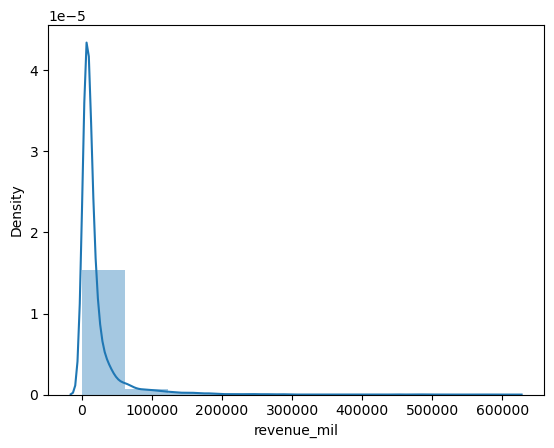

In [14]:
data = df['revenue_mil']
sns.distplot(data, bins=10, hist=True, kde=True, label = 'Revenue (in millions)')

The above confirms that Revenue(in millions) is positively (right) skewed.

## Computation of Measures of Dispersion or Variability:

In [15]:
#minimum value:
df['revenue_mil'].min()

48.29

In [16]:
#maximum value:
df['revenue_mil'].max()

611289.0

In [17]:
#Range
df['revenue_mil'].max() - df['revenue_mil'].min()

611240.71

In [18]:
# Variance
df['revenue_mil'].var()

1295569727.4622889

In [19]:
# Standard Deviation
df['revenue_mil'].std()

35994.0234964402

In [20]:
# Median (Q2 or 50th percentile)
Q2 = df['revenue_mil'].quantile(0.5)
print(Q2)

9587.5


In [21]:
# Q3 or 75th percentile
Q3 = df['revenue_mil'].quantile(0.75)
print(Q3)

19109.0


In [22]:
# Q1 or 25th percentile
Q1 = df['revenue_mil'].quantile(0.25)
print(Q1)

5806.225


In [23]:
# Interquartile Range
IQR = Q3 - Q1
print(IQR)

13302.775


**Box Plot of Revenue (in millions):**

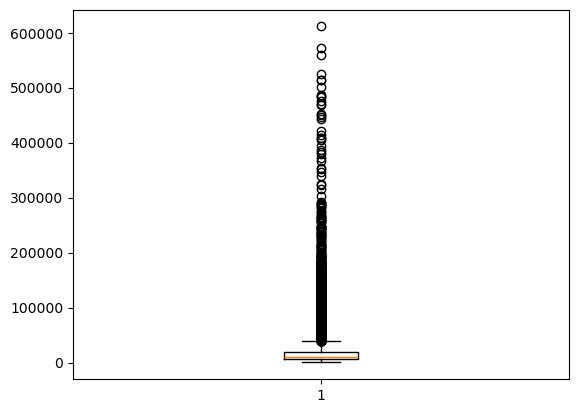

In [24]:
plt.boxplot(eda_df['revenue_mil'])
plt.show()

**Insights:**
* Dots outside Whiskers are Outliers, which represent extreme revenue values
* Very large companies (Walmart, Amazon, etc.)
* Outliers are important insights, not errors.
* Right-skewed distribution with a few very large companies dominating revenue.
* The boxplot shows that most Fortune 500 companies have moderate revenues, while a small number of companies generate extremelyhigh revenues, creating right skewness and many upper outliers.

## Computation of Measures of Shape of distribution:

**Skewness:**

In [25]:
df_skew = eda_df['revenue_mil'].skew()
print(df_skew)

6.355594826690244


We find the skewness to be 6.355, which is greater than 1. So, we can conclude that the Revenue (in millions) data is **highly skewed**.

**Kurtosis:**

In [26]:
df_kurt = eda_df['revenue_mil'].kurt()
print(df_kurt)

60.288317854502594


We find the kurtosis to be 60.28, which is greater than 3. So, we can conclude that the Revenue (in millions) curve is a **leptokurtic curve**. As
compared to a normal distribution, its central peak is higher and sharper, and its tails are longer and fatter.

## Univariate Analysis (single column):

**a) Distribution of Revenue:**

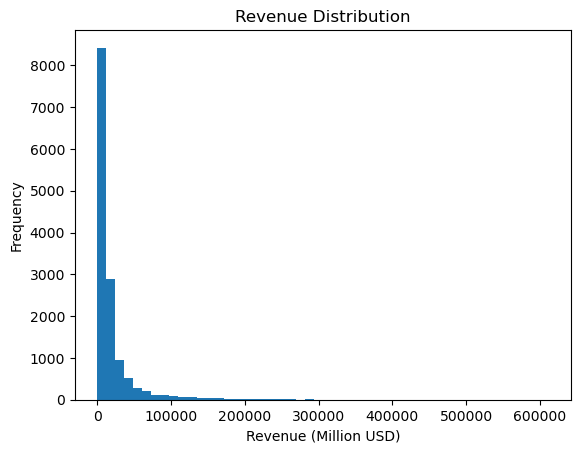

In [27]:
import matplotlib.pyplot as plt
plt.hist(eda_df['revenue_mil'], bins=50)
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.show()

**Insights:**
* Right-skewed distribution.
* Few companies earn extremely high revenue.

**a) Distribution of Profit:**

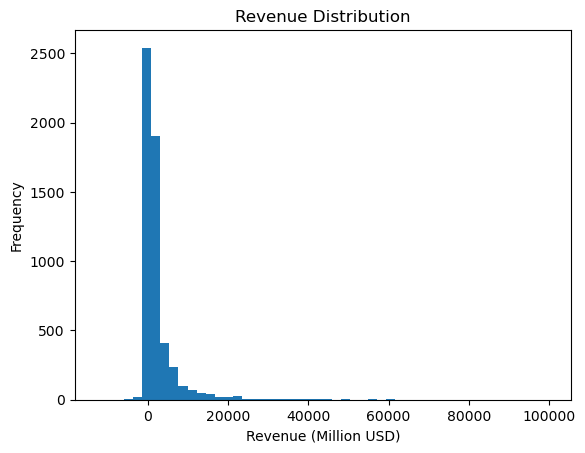

In [28]:
import matplotlib.pyplot as plt
plt.hist(eda_df['profit_mil'], bins=50)
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.show()

There are both profits and losses.

## Bivariate Analysis (relationship between columns):

**a) Revenue vs Profit:**

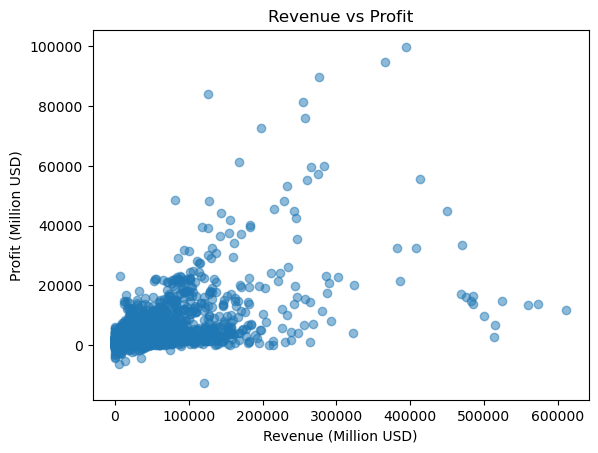

In [29]:
plt.scatter(
eda_df['revenue_mil'],
eda_df['profit_mil'],
alpha=0.5
)
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Profit (Million USD)")
plt.title("Revenue vs Profit")
plt.show()

**Insights:**
* higher revenues doesn't always mean higher profits
* there are companies making losses despite having high revenues

**b) Rank vs Revenue:**

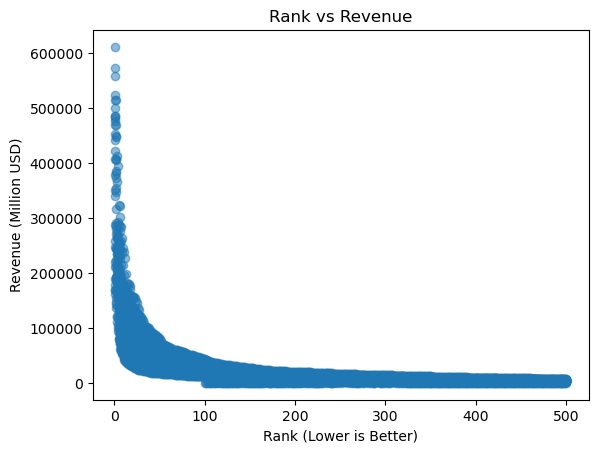

In [30]:
plt.scatter(
eda_df['rank'],
eda_df['revenue_mil'],
alpha=0.5
)
plt.xlabel("Rank (Lower is Better)")
plt.ylabel("Revenue (Million USD)")
plt.title("Rank vs Revenue")
plt.show()

**Insights:**
* Lower rank → higher revenue
* We see a Strong inverse relationship

## Trend Analysis Over Time:

**a) Average Revenue by Year:**

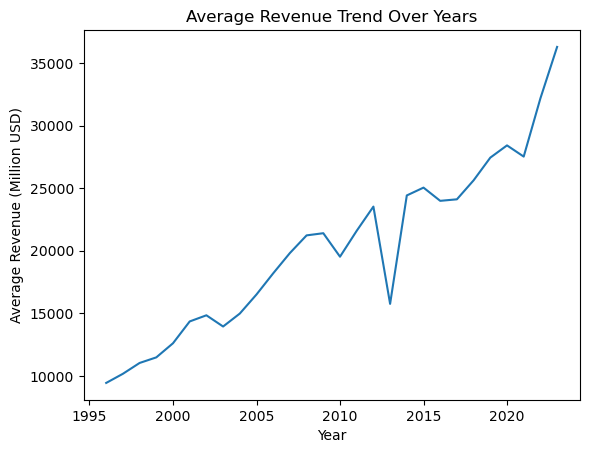

In [31]:
yearly_revenue = eda_df.groupby('year')['revenue_mil'].mean()
plt.plot(yearly_revenue.index, yearly_revenue.values)
plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.title("Average Revenue Trend Over Years")
plt.show()

We see ups and downs in growth over a period of time. Overall there's a positive growth trend.

**b) Average Profit by Year:**

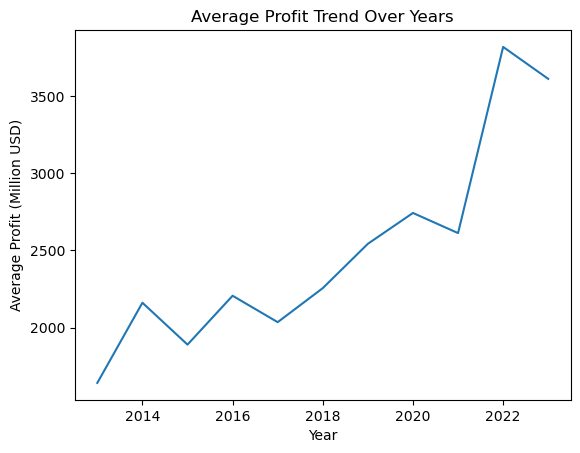

In [32]:
yearly_profit = eda_df.groupby('year')['profit_mil'].mean()
plt.plot(yearly_profit.index, yearly_profit.values)
plt.xlabel("Year")
plt.ylabel("Average Profit (Million USD)")
plt.title("Average Profit Trend Over Years")
plt.show()

## Company-Level Insights:

**Top 10 Companies by Revenue (Latest Year):**

In [33]:
latest_year = eda_df['year'].max()
top_companies = (
    eda_df[eda_df['year'] == latest_year]
        .sort_values(by='revenue_mil', ascending=False)
        .head(10)
)

top_companies[['industry', 'revenue_mil', 'profit_mil']]

,industry,revenue_mil,profit_mil
13440,General Merchandisers,611289.0,11680.0
13441,Internet Services and Retailing,513983.0,2722.0
13442,Petroleum Refining,413680.0,55740.0
13443,"Computers, Office Equipment",394328.0,99803.0
13444,Health Care: Insurance and Managed Care,324162.0,20120.0
13445,Health Care: Pharmacy and Other Services,322467.0,4149.0
13446,Insurance: Property and Casualty (Stock),302089.0,22819.0
13447,Internet Services and Retailing,282836.0,59972.0
13448,Wholesalers: Health Care,263966.0,1114.0
13449,Petroleum Refining,246252.0,35465.0


**Revenue Distribution by Year: Boxplot**

<Figure size 1200x600 with 0 Axes>

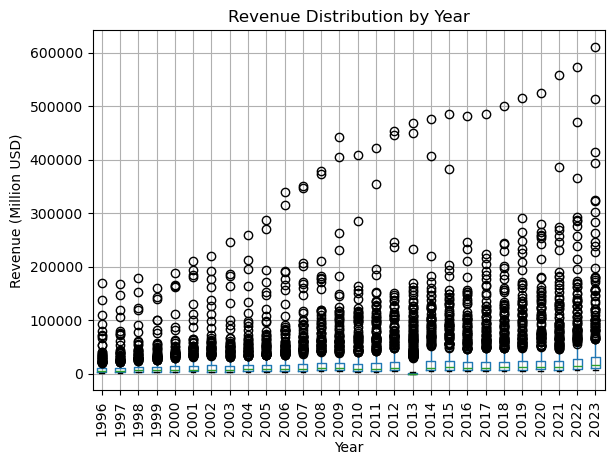

In [34]:
plt.figure(figsize=(12,6))
df.boxplot(column='revenue_mil', by='year', rot=90)
plt.xlabel("Year")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue Distribution by Year")
plt.suptitle("") # remove default subtitle
plt.show()

**Insights:**
* One box = one year.
* The box shows the middle 50% of company revenues in that year.
* Dots above the whisker = very large companies (outliers)
* Median revenue increases over time (moves upward year by year)
* The typical Fortune 500 company’s revenue has increased steadily over the years.
* Revenue dispersion widens over time, showing that top companies are pulling further ahead.
* Economic growth disproportionately benefits the largest firms (Many high dots in later years reflects rise of mega-corporations).

**Revenue Distribution by Industry (Top 10): Boxplot**

In [35]:
top_10_industries = df['industry'].value_counts().head(10).index
df_top10 = df[df['industry'].isin(top_10_industries)]

<Figure size 1400x600 with 0 Axes>

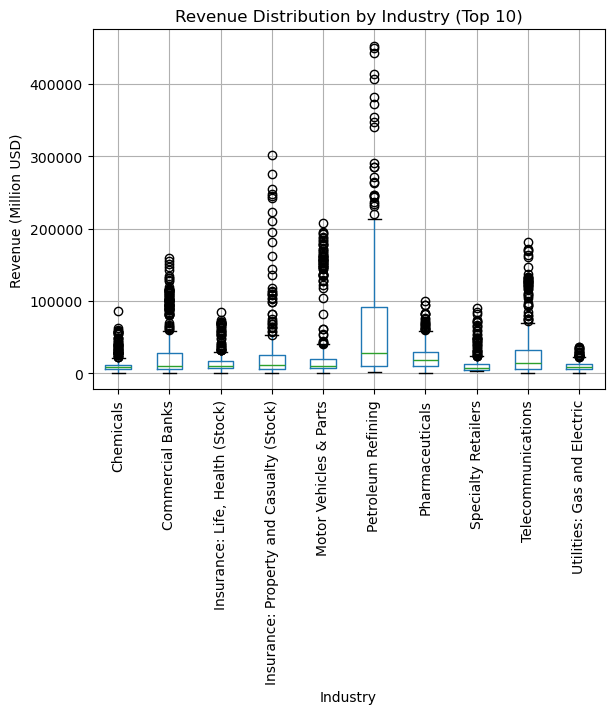

In [36]:
plt.figure(figsize=(14,6))
df_top10.boxplot(
column='revenue_mil',
by='industry',
rot=90
)
plt.xlabel("Industry")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue Distribution by Industry (Top 10)")
plt.suptitle("") # remove automatic subtitle
plt.show()

**Insights:**
* Each box represent one industry.
* Median revenue → typical company size.
* Box height (IQR) → variability within industry.
* Outliers → dominant players.
* Petroleum refining companies generate significantly higher revenues than most other industries.
* Banks & Telecommunications have high variability (moderate median, large number of outliers).
* Utilities & Chemicals are more stable. These industries show more predictable and regulated revenue patterns.
* The analysis shows increasing revenue growth over time, rising inequality among companies, and strong industry-level differences, with
petroleum refining and banking showing the highest variability and outliers.